Loaded 839 NHDA polygons
0    22.68
2    19.60
4    22.58
6    24.43
8    23.51
Name: nhda_built_up_ratio, dtype: float64


C:\Users\agz90fk\AppData\Local\Temp\ipykernel_22452\732143214.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Saved: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda\nhda_built_up_ratio_violin_regbez.jpg


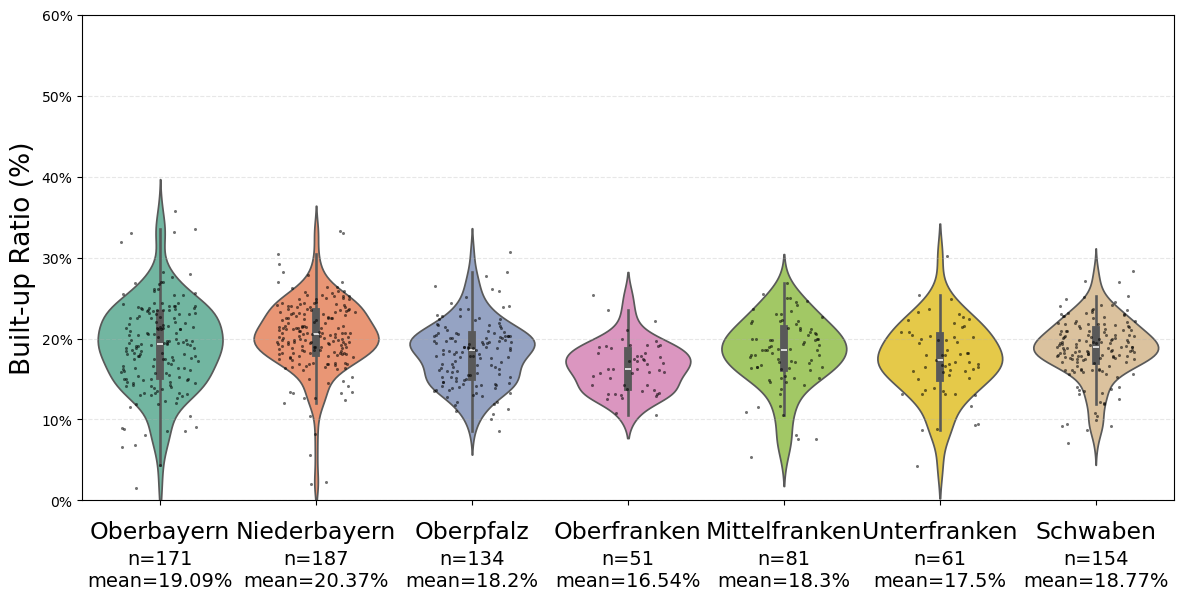


Summary statistics by Regierungsbezirk:
               count   mean   std    min    max
regbez                                         
Oberbayern       171  19.09  5.54   1.54  35.72
Niederbayern     187  20.37  4.44   1.98  33.28
Oberpfalz        134  18.20  3.95   8.63  30.66
Oberfranken       51  16.54  3.09  10.52  25.39
Mittelfranken     81  18.30  4.32   5.37  26.84
Unterfranken      61  17.50  4.57   4.27  30.18
Schwaben         154  18.77  3.75   7.14  28.39

Overall summary (all NHDAs):
count    839.00
mean      18.83
std        4.54
min        1.54
max       35.72
p5        11.48
p10       13.21
p90       24.08
p95       25.53
Name: nhda_built_up_ratio, dtype: float64

NHDA with lowest built-up ratio:  nhda_id=09186_14, value=1.54%
NHDA with highest built-up ratio: nhda_id=09175_8, value=35.72%

Usable share columns: ['nhda_res_subclass_share_sfh_db', 'nhda_res_subclass_share_sbd', 'nhda_res_subclass_share_tb', 'nhda_res_subclass_share_mfh_ab']
Saved: C:\Users\agz90fk\Docum

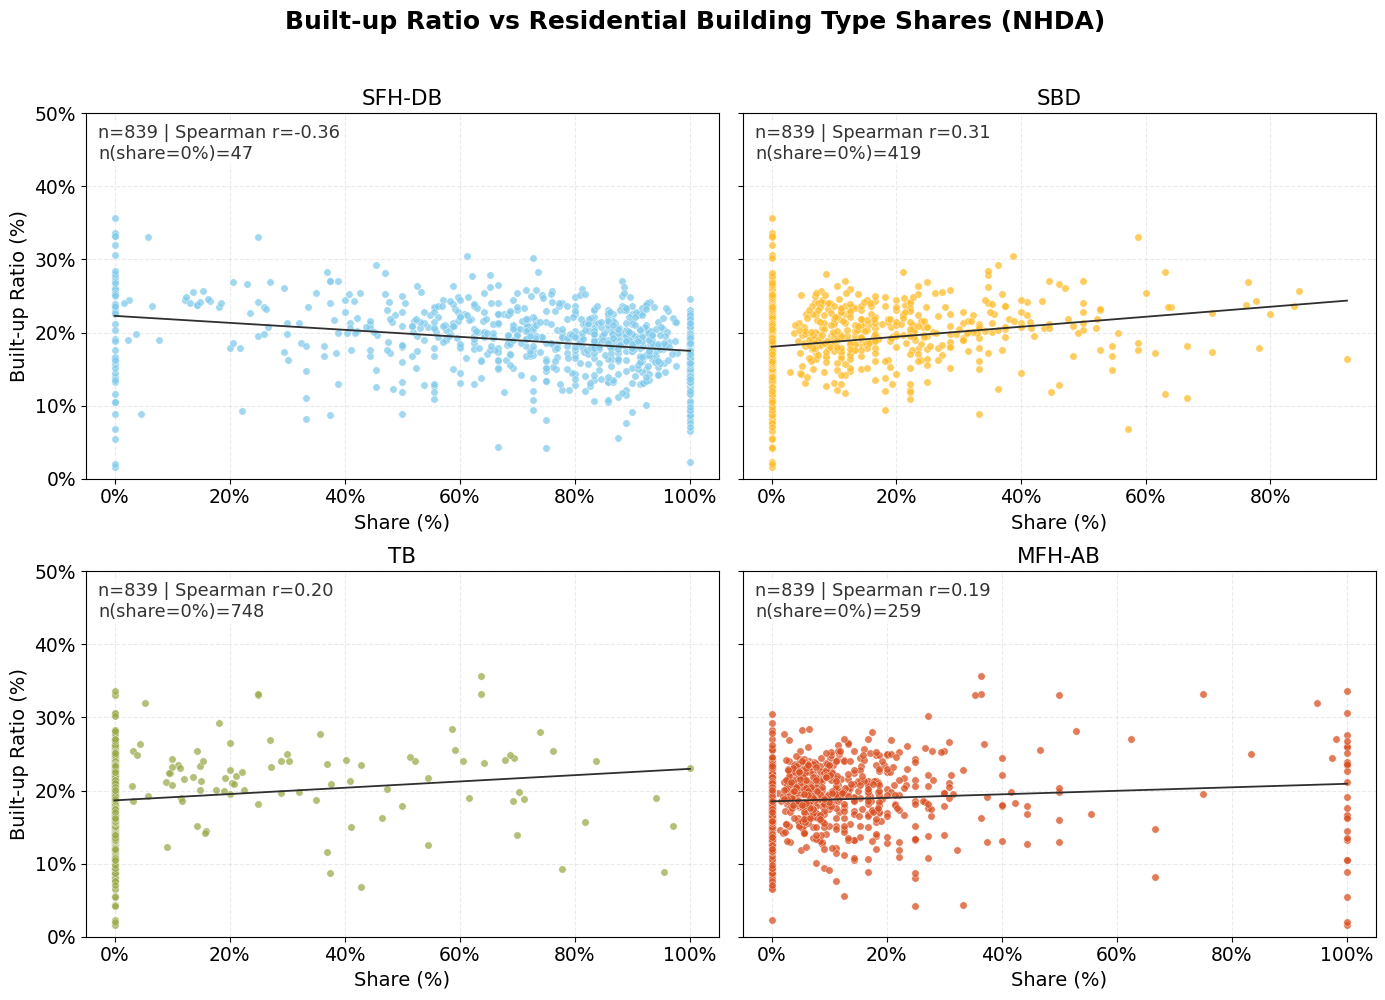

In [24]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from pathlib import Path

# Load the building structure analysis result
gpkg_file = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Comparison_NHDA_RA\Comparison_LST_NDVI_DEGURB_CLC_BuildingStructure.gpkg"

gdf = gpd.read_file(gpkg_file)

# Filter to NHDA only
gdf_nhda = gdf[gdf['type'] == 'NHDA'].copy()
print(f"Loaded {len(gdf_nhda)} NHDA polygons")

# Extract Regierungsbezirk from ARS (first 3 digits)
regbez_map = {
    '091': 'Oberbayern',
    '092': 'Niederbayern',
    '093': 'Oberpfalz',
    '094': 'Oberfranken',
    '095': 'Mittelfranken',
    '096': 'Unterfranken',
    '097': 'Schwaben',
}

gdf_nhda['ARS'] = gdf_nhda['nhda_id'].astype(str).str.zfill(5)
gdf_nhda['regbez_code'] = gdf_nhda['ARS'].str[:3]
gdf_nhda['regbez'] = gdf_nhda['regbez_code'].map(regbez_map)

# Convert built-up ratio to numeric (stored as percent values, e.g., 22.68)
gdf_nhda['nhda_built_up_ratio'] = pd.to_numeric(gdf_nhda['nhda_built_up_ratio'], errors='coerce')
print(gdf_nhda['nhda_built_up_ratio'].head())
# Remove rows with missing regbez or built_up_ratio
gdf_nhda = gdf_nhda.dropna(subset=['regbez', 'nhda_built_up_ratio'])

regbez_order = ['Oberbayern', 'Niederbayern', 'Oberpfalz', 'Oberfranken', 'Mittelfranken', 'Unterfranken', 'Schwaben']
n_counts = gdf_nhda.groupby('regbez').size().reindex(regbez_order).fillna(0).astype(int)
mean_vals = gdf_nhda.groupby('regbez')['nhda_built_up_ratio'].mean().reindex(regbez_order).fillna(0).round(2)
xtick_labels = [f"{rb}\nn={n_counts[rb]} \nmean={mean_vals[rb]}" for rb in regbez_order]

# Create violin plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=gdf_nhda,
    x='regbez',
    y='nhda_built_up_ratio',
    order=regbez_order,
    palette='Set2',
    ax=ax
)
sns.stripplot(
    data=gdf_nhda,
    x='regbez',
    y='nhda_built_up_ratio',
    order=regbez_order,
    color='black',
    size=2.2,
    alpha=0.55,
    jitter=0.25,
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('Built-up Ratio (%)', fontsize=19)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 60)
ax.yaxis.set_major_locator(mtick.MultipleLocator(10))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax.set_xticklabels([])
ylim = ax.get_ylim()
y_pos_large = ylim[0] - (ylim[1] - ylim[0]) * 0.04
y_pos_small = ylim[0] - (ylim[1] - ylim[0]) * 0.10

for i, regbez in enumerate(regbez_order):
    ax.text(i, y_pos_large, regbez, ha='center', va='top', fontsize=17)
    ax.text(i, y_pos_small, f"n={n_counts[regbez]}\nmean={mean_vals[regbez]}%",
            ha='center', va='top', fontsize=14)

plt.subplots_adjust(bottom=0.25)
plt.tight_layout()

# Save
output_dir = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda")
output_dir.mkdir(parents=True, exist_ok=True)
out_file = output_dir / 'nhda_built_up_ratio_violin_regbez.jpg'
plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out_file}")

plt.show()

# Summary statistics by Regierungsbezirk
print("\nSummary statistics by Regierungsbezirk:")
summary = gdf_nhda.groupby('regbez')['nhda_built_up_ratio'].agg(['count', 'mean', 'std', 'min', 'max'])
summary = summary.reindex(regbez_order)
print(summary.round(2))

# Overall summary across all NHDAs
print("\nOverall summary (all NHDAs):")
overall = gdf_nhda['nhda_built_up_ratio'].agg(['count', 'mean', 'std', 'min', 'max'])
overall_quantiles = gdf_nhda['nhda_built_up_ratio'].quantile([0.05, 0.10, 0.90, 0.95])
overall_quantiles.index = ['p5', 'p10', 'p90', 'p95']
overall = pd.concat([overall, overall_quantiles])
print(overall.round(2))

# NHDA IDs with min and max built-up ratio
idx_min = gdf_nhda['nhda_built_up_ratio'].idxmin()
idx_max = gdf_nhda['nhda_built_up_ratio'].idxmax()
print(f"\nNHDA with lowest built-up ratio:  nhda_id={gdf_nhda.loc[idx_min, 'nhda_id']}, value={gdf_nhda.loc[idx_min, 'nhda_built_up_ratio']:.2f}%")
print(f"NHDA with highest built-up ratio: nhda_id={gdf_nhda.loc[idx_max, 'nhda_id']}, value={gdf_nhda.loc[idx_max, 'nhda_built_up_ratio']:.2f}%")

# ---------------------------------------------------------------------------
# 2x2 scatterplots: built-up ratio vs residential building type shares
# ---------------------------------------------------------------------------

# Column names, labels and colors aligned with color theme
scatter_config = [
    ("nhda_res_subclass_share_sfh_db", "SFH-DB", "#82cbec"),  # Blue   (top-left)
    ("nhda_res_subclass_share_sbd",    "SBD",    "#febd2b"),  # Yellow (top-right)
    ("nhda_res_subclass_share_tb",     "TB",     "#9aab4b"),  # Green  (bottom-left)
    ("nhda_res_subclass_share_mfh_ab", "MFH-AB", "#d94f21"),  # Red    (bottom-right)
]

# Verify columns exist and have data
usable_config = []
for col, label, color in scatter_config:
    if col not in gdf_nhda.columns:
        print(f"WARNING: Column not found: {col}")
        continue
    vals = pd.to_numeric(gdf_nhda[col], errors="coerce")
    if vals.notna().sum() >= 10:
        usable_config.append((col, label, color))
    else:
        print(f"WARNING: Not enough data in column: {col}")

print(f"\nUsable share columns: {[c for c, _, _ in usable_config]}")

if len(usable_config) < 4:
    print("\nNot enough residential share columns found for 4 scatterplots.")
    print("Available columns containing 'share':")
    for c in gdf_nhda.columns:
        if "share" in c.lower():
            print(f" - {c}")
else:
    fig_sc, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    axes = axes.flatten()
    y = gdf_nhda["nhda_built_up_ratio"]

    for i, (col, label, color) in enumerate(usable_config):
        ax_sc = axes[i]
        x_raw = pd.to_numeric(gdf_nhda[col], errors="coerce")

        # If values look like 0..1 ratios, convert to percent for readability
        x = x_raw * 100 if x_raw.dropna().max() <= 1.5 else x_raw

        mask = x.notna() & y.notna()
        x_plot = x[mask]
        y_plot = y[mask]

        ax_sc.scatter(
            x_plot,
            y_plot,
            s=28,
            color=color,
            alpha=0.75,
            edgecolors="white",
            linewidths=0.35,
            zorder=3,
        )

        # Simple linear trend line
        if len(x_plot) >= 3:
            coeffs = np.polyfit(x_plot, y_plot, 1)
            x_line = np.linspace(x_plot.min(), x_plot.max(), 200)
            y_line = coeffs[0] * x_line + coeffs[1]
            ax_sc.plot(x_line, y_line, color="#2f2f2f", linewidth=1.3, zorder=4)

        corr = x_plot.corr(y_plot, method="spearman") if len(x_plot) > 2 else np.nan
        n_zero = (x_plot == 0).sum()

        ax_sc.set_title(label, fontsize=15.5)
        ax_sc.set_xlabel("Share (%)", fontsize=14)
        ax_sc.grid(alpha=0.25, linestyle="--", zorder=1)
        ax_sc.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
        ax_sc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
        ax_sc.tick_params(labelsize=13.5)
        ax_sc.text(
            0.02,
            0.97,
            f"n={len(x_plot)} | Spearman r={corr:.2f}\nn(share=0%)={n_zero}",
            transform=ax_sc.transAxes,
            ha="left",
            va="top",
            fontsize=12.8,
            color="#333333",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2),
        )

    for ax_sc in axes:
        ax_sc.set_ylim(0, 50)

    axes[0].set_ylabel("Built-up Ratio (%)", fontsize=14)
    axes[2].set_ylabel("Built-up Ratio (%)", fontsize=14)

    fig_sc.suptitle(
        "Built-up Ratio vs Residential Building Type Shares (NHDA)",
        fontsize=18,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out_scatter = output_dir / "nhda_built_up_ratio_vs_residential_shares_2x2.jpg"
    plt.savefig(out_scatter, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out_scatter}")
    plt.show()


In [8]:
# Debug: list layers in the source GPKG
import fiona

layers = fiona.listlayers(gpkg_file)
print("Layers in gpkg_file:")
for lyr in layers:
    print(" -", lyr)


Layers in gpkg_file:
 - Comparison_LST_NDVI_DEGURB_CLC_BuildingStructure


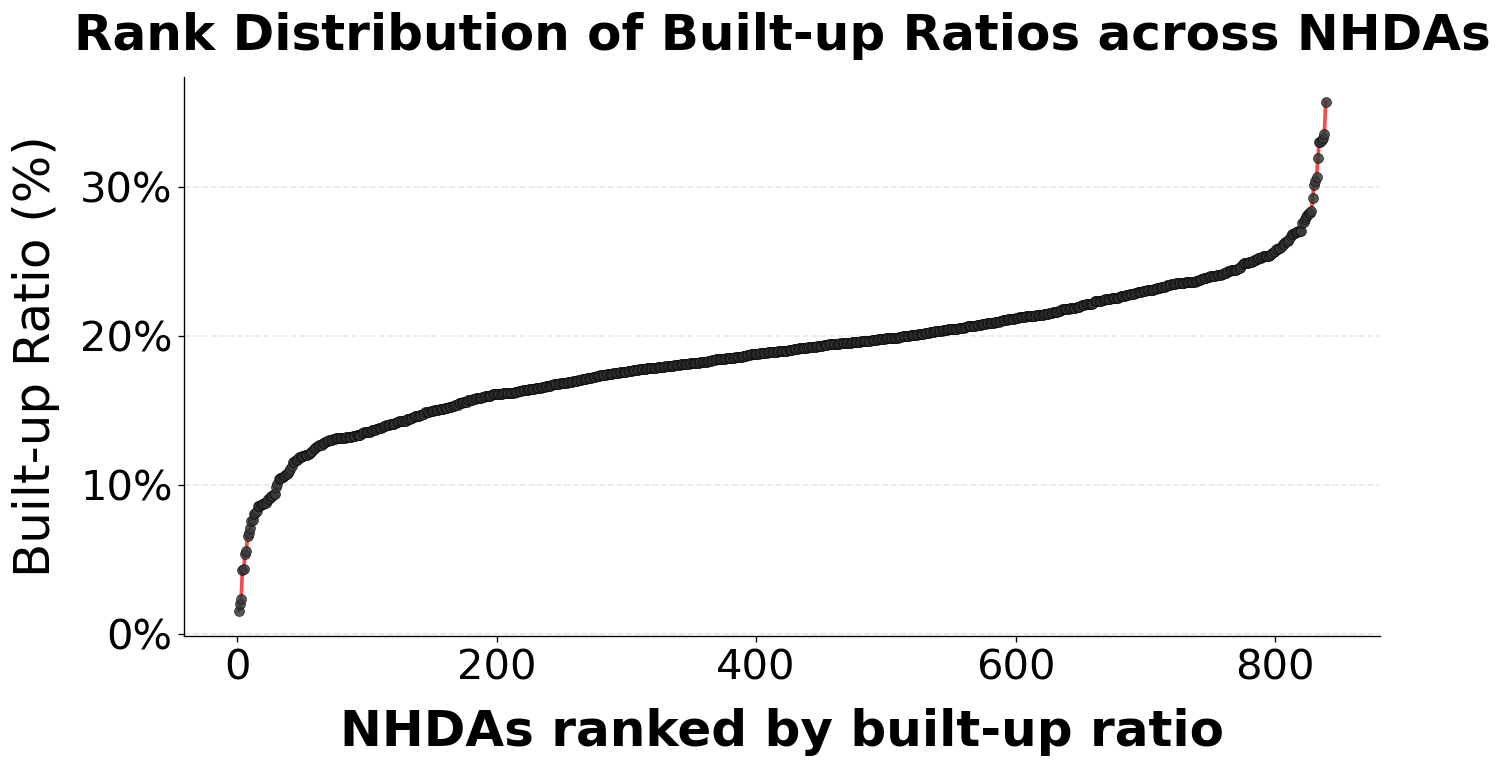

In [21]:
# Compact + cleaner rank plot of built-up ratios across NHDAs
plot_df = (
    gdf_nhda[["nhda_built_up_ratio"]]
    .rename(columns={"nhda_built_up_ratio": "built_up_ratio"})
    .dropna()
    .sort_values("built_up_ratio")
    .reset_index(drop=True)
)
plot_df["rank"] = np.arange(1, len(plot_df) + 1)

fig, ax = plt.subplots(figsize=(11.7, 6.5), dpi=120)



ax.scatter(
    plot_df["rank"],
    plot_df["built_up_ratio"],
    s=36,
    color="#3a3a3a",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.35,
    zorder=3,
)
ax.plot(
    plot_df["rank"],
    plot_df["built_up_ratio"],
    color="#f03a3a",
    linewidth=2.2,
    alpha=0.9,
    zorder=2,
)
ax.set_xlabel("NHDAs ranked by built-up ratio", fontsize=30, fontweight="bold", labelpad=12)
ax.set_ylabel("Built-up Ratio (%)", fontsize=30, labelpad=12)
ax.set_title("Rank Distribution of Built-up Ratios across NHDAs", fontsize=30, fontweight="bold", pad=16)
ax.tick_params(axis="both", labelsize=25)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.grid(axis="y", linestyle="--", alpha=0.28, linewidth=1.0, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.text(
#     0.01,
#     0.98,
#     f"n={len(plot_df)} | mean={plot_df['built_up_ratio'].mean():.1f}% | median={plot_df['built_up_ratio'].median():.1f}%",
#     transform=ax.transAxes,
#     ha="left",
#     va="top",
#     fontsize=16,
#     fontweight="bold",
#     color="#222222",
#     bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=3),
# )

fig.tight_layout()

out_scatter = output_dir / "rank_distribution_built_up_ratio.jpg"
plt.savefig(out_scatter, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()